In [1]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Генерация синтетических данных 

In [3]:
import pandas as pd
import numpy as np
import random

# Фиксация генераторов для воспроизводимости
np.random.seed(42)
random.seed(42)

# Страны и количество пользователей на каждую
countries = ['India', 'USA', 'Germany', 'Australia', 'Canada', 'France', 'UK', 'China', 'Brazil', 'Japan']
users_per_country = 100  # 100 пользователей на страну
num_users = users_per_country * len(countries)

# Товары по странам
products_by_country = {
    'India': ['spices', 'sari', 'tandoori', 'yoga mat', 'bollywood DVD'],
    'USA': ['burger', 'fastfood', 'smartphone', 'laptop', 'tablet'],
    'Germany': ['beer', 'pretzel', 'sausage', 'smartwatch', 'bicycle'],
    'Australia': ['surfboard', 'flipflops', 'australian wine', 'campsite tent', 'sunglasses'],
    'Canada': ['maple syrup', 'ski equipment', 'hockey sticks', 'smartphone', 'tablet'],
    'France': ['wine', 'baguette', 'fashion dress', 'lipstick', 'perfume'],
    'UK': ['tea set', 'fish and chips', 'smartphone', 'jacket', 'teddy bear'],
    'China': ['tea pot', 'chopsticks', 'panda toy', 'laptop', 'phone'],
    'Brazil': ['samba music', 'football', 'flip flops', 'bikini', 'sun glasses'],
    'Japan': ['sushi kit', 'kimono', 'robot vacuum', 'japanese tea set', 'bento box']
}

# Глобальные (нейтральные) товары
global_products = ['smartphone', 'laptop', 'headphones', 't-shirt', 'backpack', 'power bank']

# Цены
price_ranges = {
    'spices': (5, 30), 'sari': (10, 200), 'tandoori': (15, 40), 'yoga mat': (20, 50), 'bollywood DVD': (5, 25),
    'burger': (5, 20), 'fastfood': (10, 30), 'smartphone': (100, 1000), 'laptop': (300, 1500), 'tablet': (150, 700),
    'beer': (3, 10), 'pretzel': (2, 8), 'sausage': (4, 15), 'smartwatch': (50, 500), 'bicycle': (100, 700),
    'surfboard': (100, 600), 'flipflops': (10, 50), 'australian wine': (20, 200), 'campsite tent': (30, 300), 'sunglasses': (15, 100),
    'maple syrup': (10, 50), 'ski equipment': (100, 500), 'hockey sticks': (20, 150),
    'wine': (20, 300), 'baguette': (1, 5), 'fashion dress': (30, 200), 'lipstick': (10, 50), 'perfume': (50, 300),
    'tea set': (10, 50), 'fish and chips': (5, 15), 'jacket': (50, 300), 'teddy bear': (5, 30),
    'tea pot': (15, 50), 'chopsticks': (5, 15), 'panda toy': (10, 40), 'phone': (100, 1000),
    'samba music': (10, 30), 'football': (20, 100), 'flip flops': (5, 30), 'bikini': (20, 100), 'sun glasses': (10, 100),
    'sushi kit': (20, 80), 'kimono': (50, 500), 'robot vacuum': (100, 700), 'japanese tea set': (30, 100), 'bento box': (10, 50),
    'headphones': (50, 300), 't-shirt': (10, 40), 'backpack': (30, 150), 'power bank': (20, 80)
}

# Культурная выраженность: доля покупок из локальных товаров
cultural_expression = {
    'USA': 0.3,
    'Germany': 0.5,
    'Japan': 0.8,
    'India': 0.6,
    'France': 0.7,
    'UK': 0.5,
    'Brazil': 0.4,
    'Australia': 0.5,
    'Canada': 0.5,
    'China': 0.6
}

# Списки для хранения
data = []
user_counter = 1
for country in countries:
    for _ in range(users_per_country):
        user_id = user_counter
        user_counter += 1
        for _ in range(random.randint(5, 15)):
            if random.random() < cultural_expression[country]:
                product = random.choice(products_by_country[country])
            else:
                product = random.choice(global_products)
            price_min, price_max = price_ranges[product]
            price = round(random.uniform(price_min, price_max), 2)
            rating = random.choices([1, 2, 3, 4, 5], weights=[0.05, 0.1, 0.15, 0.3, 0.4])[0]
            data.append([user_id, country, product, price, rating])

df = pd.DataFrame(data, columns=['User_ID', 'Country', 'Product', 'Price', 'Rating'])

df.head(10)

,User_ID,Country,Product,Price,Rating
0,1,India,tandoori,21.12,2
1,1,India,bollywood DVD,6.74,4
2,1,India,sari,54.21,5
3,1,India,bollywood DVD,13.39,4
4,1,India,spices,23.97,3
5,1,India,tandoori,18.89,5
6,1,India,spices,14.50,4
7,1,India,tandoori,35.18,5
8,1,India,yoga mat,22.36,3
9,1,India,headphones,194.34,5


# БАЗОВЫЙ EDA

In [5]:
df.describe()

,User_ID,Price,Rating
count,10060.000000,10060.000000,10060.000000
mean,500.076740,227.197179,3.911531
std,288.628422,317.695989,1.174812
min,1.000000,1.040000,1.000000
25%,249.750000,28.627500,3.000000
50%,500.000000,74.940000,4.000000
75%,748.000000,276.672500,5.000000
max,1000.000000,1499.580000,5.000000


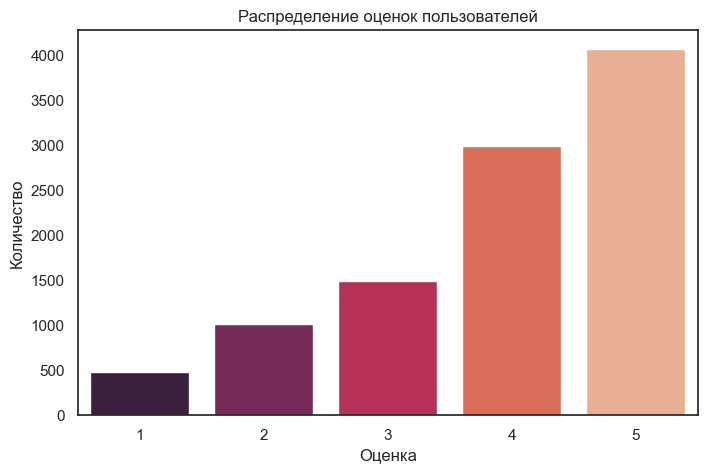

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")
plt.figure(figsize=(8, 5))
sns.countplot(x="Rating", data=df, palette="rocket")
plt.title("Распределение оценок пользователей")
plt.xlabel("Оценка")
plt.ylabel("Количество")
plt.savefig(f"ratings", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
df['Country'].unique()

array(['India', 'USA', 'Germany', 'Australia', 'Canada', 'France', 'UK',
       'China', 'Brazil', 'Japan'], dtype=object)

# ГИПОТЕЗА №1:

Формулировка:
Локальные рекомендательные модели, обученные только на пользовательских данных одной страны, могут обеспечивать более высокую точность рекомендаций для этой страны по сравнению с глобальной моделью, обученной на объединённых мультикультурных данных.


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [11]:
# Подготовка данных
df_filtered = df[['User_ID', 'Product', 'Rating', 'Country']].dropna()
df_encoded_rf = df_filtered.copy()
le_user = LabelEncoder()
le_product = LabelEncoder()
df_encoded_rf['User_ID'] = le_user.fit_transform(df_encoded_rf['User_ID'])
df_encoded_rf['Product'] = le_product.fit_transform(df_encoded_rf['Product'])

countries = df_encoded_rf['Country'].unique()

results_svd_split = []
results_knn_split = []
results_rf_split = []

for country in countries:
    local_data = df_encoded_rf[df_encoded_rf['Country'] == country].copy()
    global_data = df_encoded_rf.copy()

    # --- Train/test split для локальных данных
    train_local, test_local = train_test_split(local_data, test_size=0.2, random_state=42)

    # --- SVD (матрица взаимодействий)
    train_matrix_local = train_local.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
    test_matrix = test_local.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
    train_matrix_local = train_matrix_local.apply(lambda x: x.fillna(x.mean()), axis=0)

    svd_local = TruncatedSVD(n_components=5, random_state=42)
    reduced_local = svd_local.fit_transform(train_matrix_local)
    reconstructed_local = np.dot(reduced_local, svd_local.components_)
    reconstructed_local = np.clip(reconstructed_local, 1, 5)

    preds_local, truths_local = [], []
    for user_id in test_matrix.index:
        if user_id in train_matrix_local.index:
            for product in test_matrix.columns:
                if product in train_matrix_local.columns:
                    true_val = test_matrix.loc[user_id, product]
                    if not np.isnan(true_val):
                        u_idx = train_matrix_local.index.get_loc(user_id)
                        p_idx = train_matrix_local.columns.get_loc(product)
                        preds_local.append(reconstructed_local[u_idx, p_idx])
                        truths_local.append(true_val)

    rmse_local = np.sqrt(mean_squared_error(truths_local, preds_local)) if preds_local else None

    train_matrix_global = global_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
    train_matrix_global = train_matrix_global.apply(lambda x: x.fillna(x.mean()), axis=0)

    svd_global = TruncatedSVD(n_components=5, random_state=42)
    reduced_global = svd_global.fit_transform(train_matrix_global)
    reconstructed_global = np.dot(reduced_global, svd_global.components_)
    reconstructed_global = np.clip(reconstructed_global, 1, 5)

    preds_global, truths_global = [], []
    for user_id in test_matrix.index:
        if user_id in train_matrix_global.index:
            for product in test_matrix.columns:
                if product in train_matrix_global.columns:
                    true_val = test_matrix.loc[user_id, product]
                    if not np.isnan(true_val):
                        u_idx = train_matrix_global.index.get_loc(user_id)
                        p_idx = train_matrix_global.columns.get_loc(product)
                        preds_global.append(reconstructed_global[u_idx, p_idx])
                        truths_global.append(true_val)

    rmse_global = np.sqrt(mean_squared_error(truths_global, preds_global)) if preds_global else None

    results_svd_split.append({
        'Country': country,
        'Local_RMSE': rmse_local,
        'Global_RMSE': rmse_global
    })

    # --- KNN & RF
    X_local_full = local_data[['User_ID', 'Product']]
    y_local_full = local_data['Rating']
    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_local_full, y_local_full, test_size=0.2, random_state=42)

    X_global = global_data[['User_ID', 'Product']]
    y_global = global_data['Rating']

    # KNN
    knn_global = KNeighborsRegressor(n_neighbors=5)
    knn_global.fit(X_global, y_global)
    knn_local = KNeighborsRegressor(n_neighbors=5)
    knn_local.fit(X_train_local, y_train_local)

    preds_global = knn_global.predict(X_test_local)
    preds_local = knn_local.predict(X_test_local)

    rmse_g = mean_squared_error(y_test_local, preds_global, squared=False)
    rmse_l = mean_squared_error(y_test_local, preds_local, squared=False)
    results_knn_split.append({'Country': country, 'Global_RMSE': rmse_g, 'Local_RMSE': rmse_l})

    # Random Forest
    rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_global.fit(X_global, y_global)
    rf_local = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_local.fit(X_train_local, y_train_local)

    preds_global = rf_global.predict(X_test_local)
    preds_local = rf_local.predict(X_test_local)

    rmse_g = mean_squared_error(y_test_local, preds_global, squared=False)
    rmse_l = mean_squared_error(y_test_local, preds_local, squared=False)
    results_rf_split.append({'Country': country, 'Global_RMSE': rmse_g, 'Local_RMSE': rmse_l})

# Создание итоговых таблиц
df_svd = pd.DataFrame(results_svd_split)
df_knn = pd.DataFrame(results_knn_split)
df_rf = pd.DataFrame(results_rf_split)


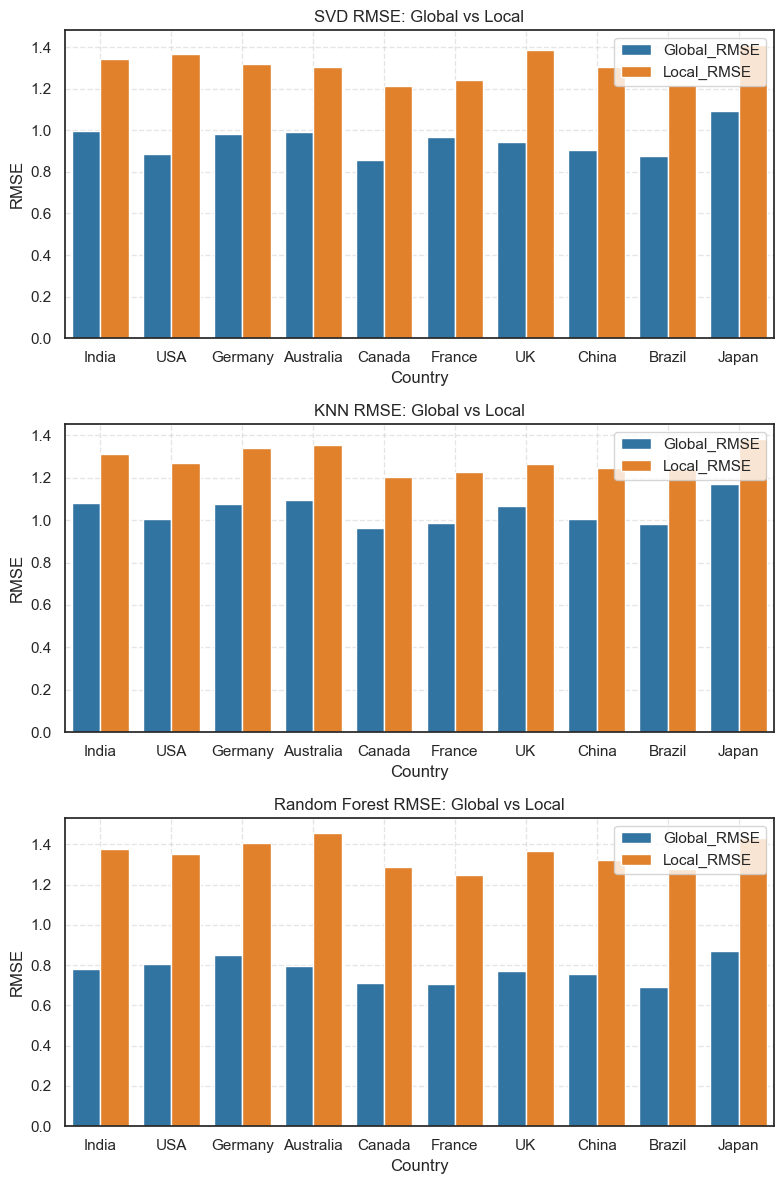

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Цветовая палитра
palette = {
    'Global_RMSE': '#1f77b4',  # насыщенный синий
    'Local_RMSE': '#ff7f0e'    # насыщенный оранжевый
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 12))

# Первый график — SVD
df_plot_svd = df_svd.melt(id_vars='Country', value_vars=['Global_RMSE', 'Local_RMSE'],
                          var_name='Model_Type', value_name='RMSE')
sns.barplot(data=df_plot_svd, x='Country', y='RMSE', hue='Model_Type', palette=palette, ax=axes[0])
axes[0].set_title('SVD RMSE: Global vs Local')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Второй график — KNN
df_plot_knn = df_knn.melt(id_vars='Country', value_vars=['Global_RMSE', 'Local_RMSE'],
                          var_name='Model_Type', value_name='RMSE')
sns.barplot(data=df_plot_knn, x='Country', y='RMSE', hue='Model_Type', palette=palette, ax=axes[1])
axes[1].set_title('KNN RMSE: Global vs Local')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Третий график — Random Forest
df_plot_rf = df_rf.melt(id_vars='Country', value_vars=['Global_RMSE', 'Local_RMSE'],
                        var_name='Model_Type', value_name='RMSE')
sns.barplot(data=df_plot_rf, x='Country', y='RMSE', hue='Model_Type', palette=palette, ax=axes[2])
axes[2].set_title('Random Forest RMSE: Global vs Local')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"H1.png", dpi=300, bbox_inches='tight')
plt.show()


# ГИПОТЕЗА №2

Формулировка:  Существует порог объема пользовательских данных, после которого локальная модель начинает превосходить глобальную по точности.

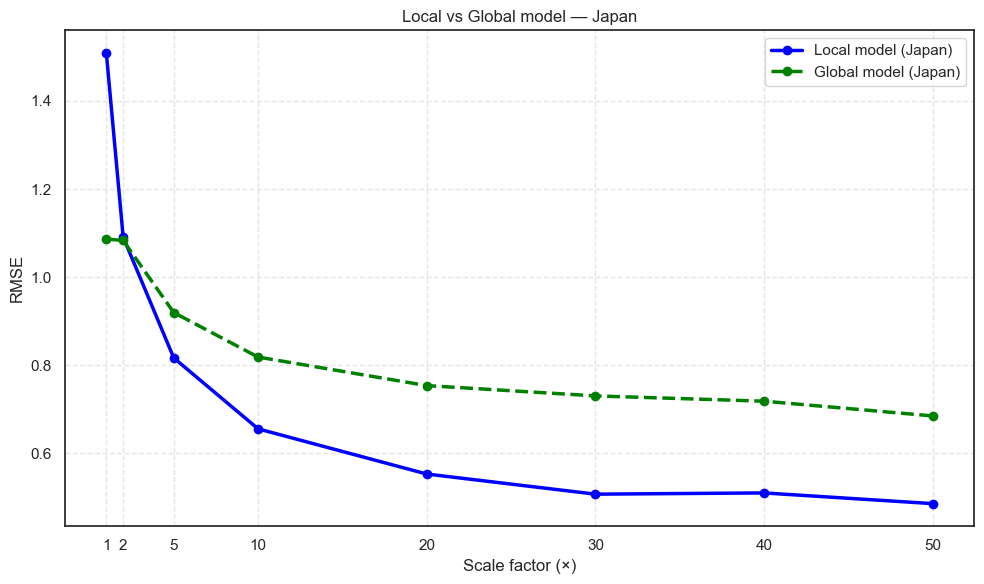

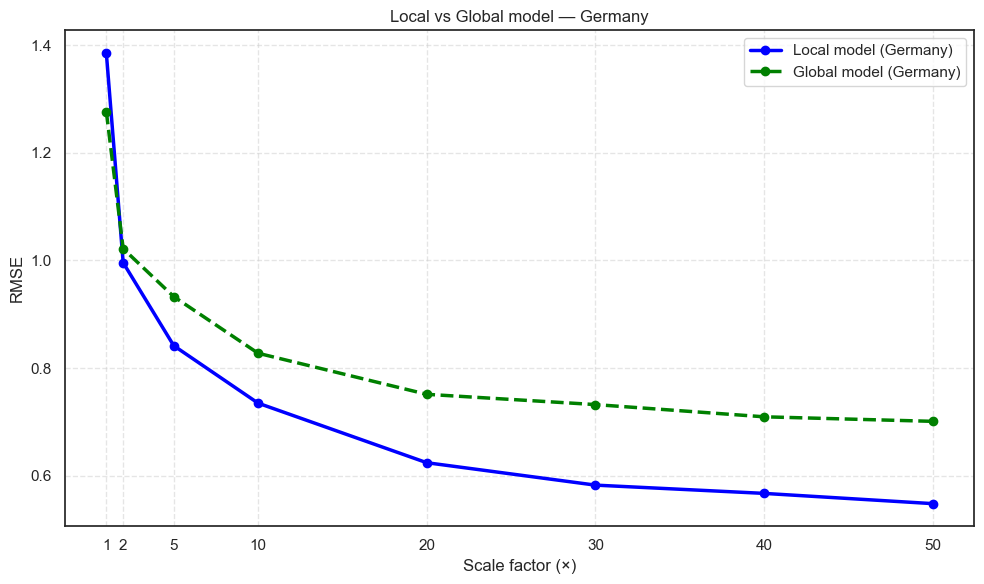

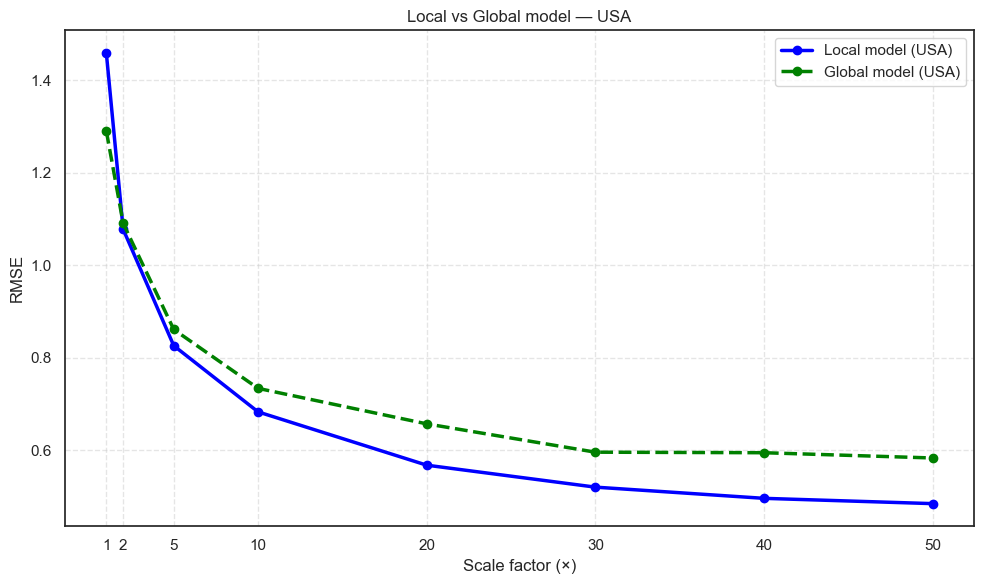

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import random
import numpy as np

random.seed(100)
np.random.seed(100)

# === Настройки
scale_factors = [1, 2, 5, 10, 20, 30, 40, 50]
target_countries = ['Japan', 'Germany', 'USA']
n_components = 5
noise_level = 0.8

# === Функция для локальной модели
def calculate_rmse_scaled_by_country(df, country, scale_factors, n_components=5):
    results = {}
    base_df = df[df['Country'] == country].copy()

    for factor in scale_factors:
        scaled_df = pd.concat([base_df] * factor, ignore_index=True)
        scaled_df['User_ID'] = scaled_df['User_ID'].astype(str) + f"_x{factor}"

        # Шум
        noise = np.random.normal(loc=0, scale=noise_level, size=len(scaled_df))
        scaled_df['Rating'] = np.clip(scaled_df['Rating'] + noise, 1, 5)

        try:
            train_data, test_data = train_test_split(scaled_df, test_size=0.2, random_state=42)
            train_matrix = train_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            test_matrix = test_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            train_matrix = train_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

            svd = TruncatedSVD(n_components=n_components, random_state=42)
            reduced = svd.fit_transform(train_matrix)
            reconstructed = np.dot(reduced, svd.components_)
            reconstructed = np.clip(reconstructed, 1, 5)

            preds, truths = [], []
            for user_id in test_matrix.index:
                if user_id in train_matrix.index:
                    for product in test_matrix.columns:
                        if product in train_matrix.columns:
                            true_val = test_matrix.loc[user_id, product]
                            if not np.isnan(true_val):
                                u_idx = train_matrix.index.get_loc(user_id)
                                p_idx = train_matrix.columns.get_loc(product)
                                preds.append(reconstructed[u_idx, p_idx])
                                truths.append(true_val)

            results[factor] = np.sqrt(mean_squared_error(truths, preds)) if preds else None
        except:
            results[factor] = None

    return results

# === Функция для глобальной модели
def calculate_global_rmse_only_target_country(df, country, scale_factors, n_components=5):
    rmse_results = {}

    for factor in scale_factors:
        country_df = df[df['Country'] == country].copy()
        other_df = df[df['Country'] != country].copy()

        scaled_country = pd.concat([country_df] * factor, ignore_index=True)
        scaled_country['User_ID'] = scaled_country['User_ID'].astype(str) + f"_x{factor}"

        # Шум
        noise = np.random.normal(loc=0, scale=noise_level, size=len(scaled_country))
        scaled_country['Rating'] = np.clip(scaled_country['Rating'] + noise, 1, 5)

        full_df = pd.concat([scaled_country, other_df], ignore_index=True)

        try:
            train_data, test_data = train_test_split(full_df, test_size=0.2, random_state=42)
            test_data = test_data[test_data['Country'] == country]

            if test_data.empty:
                rmse_results[factor] = None
                continue

            train_matrix = train_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            test_matrix = test_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            train_matrix = train_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

            svd = TruncatedSVD(n_components=n_components, random_state=42)
            reduced = svd.fit_transform(train_matrix)
            reconstructed = np.dot(reduced, svd.components_)
            reconstructed = np.clip(reconstructed, 1, 5)

            preds, truths = [], []
            for user_id in test_matrix.index:
                if user_id in train_matrix.index:
                    for product in test_matrix.columns:
                        if product in train_matrix.columns:
                            true_val = test_matrix.loc[user_id, product]
                            if not np.isnan(true_val):
                                u_idx = train_matrix.index.get_loc(user_id)
                                p_idx = train_matrix.columns.get_loc(product)
                                preds.append(reconstructed[u_idx, p_idx])
                                truths.append(true_val)

            rmse_results[factor] = np.sqrt(mean_squared_error(truths, preds)) if preds else None
        except:
            rmse_results[factor] = None

    return rmse_results

# === Визуализация
for country in target_countries:
    local_rmse = calculate_rmse_scaled_by_country(df, country, scale_factors, n_components)
    global_rmse = calculate_global_rmse_only_target_country(df, country, scale_factors, n_components)

    plt.figure(figsize=(10, 6))
    plt.plot(scale_factors, list(local_rmse.values()),
             marker='o', linewidth=2.5, label=f'Local model ({country})', color='blue')
    plt.plot(scale_factors, list(global_rmse.values()),
             marker='o', linewidth=2.5, linestyle='--', label=f'Global model ({country})', color='green')

    plt.xlabel("Scale factor (×)")
    plt.ylabel("RMSE")
    plt.title(f"Local vs Global model — {country}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(scale_factors)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"H2_{country}.png", dpi=300, bbox_inches='tight')
    plt.show()


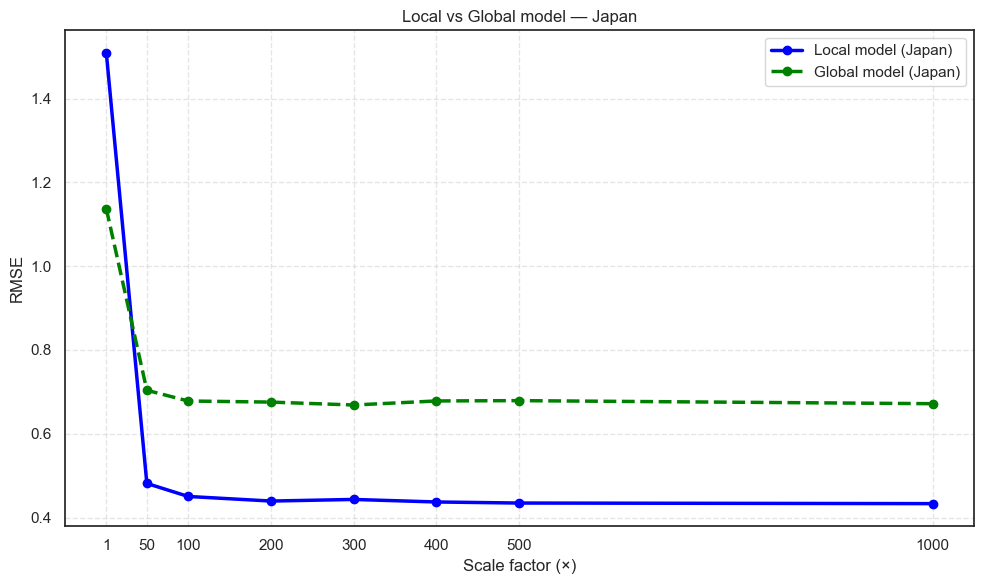

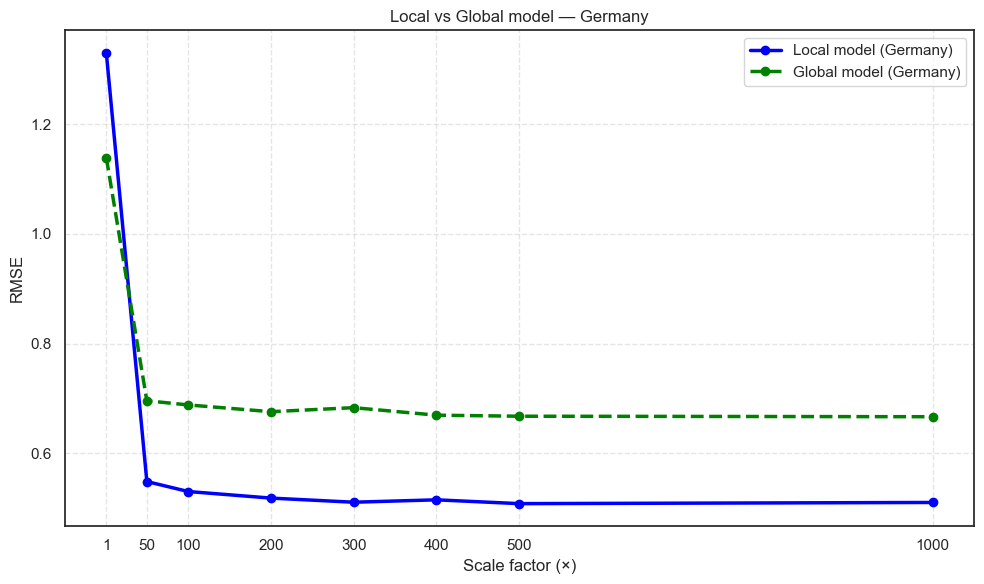

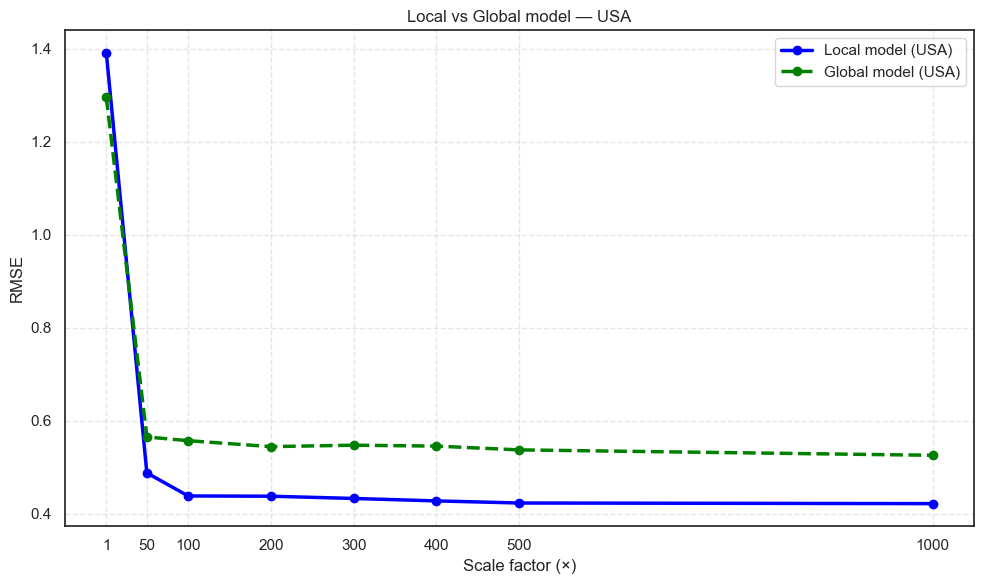

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import random
import numpy as np

random.seed(100)
np.random.seed(100)

# === Настройки
scale_factors = [1, 50, 100, 200, 300, 400, 500, 1000]
target_countries = ['Japan', 'Germany', 'USA']
n_components = 5
noise_level = 0.8

# === Функция для локальной модели
def calculate_rmse_scaled_by_country(df, country, scale_factors, n_components=5):
    results = {}
    base_df = df[df['Country'] == country].copy()

    for factor in scale_factors:
        scaled_df = pd.concat([base_df] * factor, ignore_index=True)
        scaled_df['User_ID'] = scaled_df['User_ID'].astype(str) + f"_x{factor}"

        # Шум
        noise = np.random.normal(loc=0, scale=noise_level, size=len(scaled_df))
        scaled_df['Rating'] = np.clip(scaled_df['Rating'] + noise, 1, 5)

        try:
            train_data, test_data = train_test_split(scaled_df, test_size=0.2, random_state=42)
            train_matrix = train_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            test_matrix = test_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            train_matrix = train_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

            svd = TruncatedSVD(n_components=n_components, random_state=42)
            reduced = svd.fit_transform(train_matrix)
            reconstructed = np.dot(reduced, svd.components_)
            reconstructed = np.clip(reconstructed, 1, 5)

            preds, truths = [], []
            for user_id in test_matrix.index:
                if user_id in train_matrix.index:
                    for product in test_matrix.columns:
                        if product in train_matrix.columns:
                            true_val = test_matrix.loc[user_id, product]
                            if not np.isnan(true_val):
                                u_idx = train_matrix.index.get_loc(user_id)
                                p_idx = train_matrix.columns.get_loc(product)
                                preds.append(reconstructed[u_idx, p_idx])
                                truths.append(true_val)

            results[factor] = np.sqrt(mean_squared_error(truths, preds)) if preds else None
        except:
            results[factor] = None

    return results

# === Функция для глобальной модели
def calculate_global_rmse_only_target_country(df, country, scale_factors, n_components=5):
    rmse_results = {}

    for factor in scale_factors:
        country_df = df[df['Country'] == country].copy()
        other_df = df[df['Country'] != country].copy()

        scaled_country = pd.concat([country_df] * factor, ignore_index=True)
        scaled_country['User_ID'] = scaled_country['User_ID'].astype(str) + f"_x{factor}"

        # Шум
        noise = np.random.normal(loc=0, scale=noise_level, size=len(scaled_country))
        scaled_country['Rating'] = np.clip(scaled_country['Rating'] + noise, 1, 5)

        full_df = pd.concat([scaled_country, other_df], ignore_index=True)

        try:
            train_data, test_data = train_test_split(full_df, test_size=0.2, random_state=42)
            test_data = test_data[test_data['Country'] == country]

            if test_data.empty:
                rmse_results[factor] = None
                continue

            train_matrix = train_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            test_matrix = test_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
            train_matrix = train_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

            svd = TruncatedSVD(n_components=n_components, random_state=42)
            reduced = svd.fit_transform(train_matrix)
            reconstructed = np.dot(reduced, svd.components_)
            reconstructed = np.clip(reconstructed, 1, 5)

            preds, truths = [], []
            for user_id in test_matrix.index:
                if user_id in train_matrix.index:
                    for product in test_matrix.columns:
                        if product in train_matrix.columns:
                            true_val = test_matrix.loc[user_id, product]
                            if not np.isnan(true_val):
                                u_idx = train_matrix.index.get_loc(user_id)
                                p_idx = train_matrix.columns.get_loc(product)
                                preds.append(reconstructed[u_idx, p_idx])
                                truths.append(true_val)

            rmse_results[factor] = np.sqrt(mean_squared_error(truths, preds)) if preds else None
        except:
            rmse_results[factor] = None

    return rmse_results

# === Визуализация
for country in target_countries:
    local_rmse = calculate_rmse_scaled_by_country(df, country, scale_factors, n_components)
    global_rmse = calculate_global_rmse_only_target_country(df, country, scale_factors, n_components)

    plt.figure(figsize=(10, 6))
    plt.plot(scale_factors, list(local_rmse.values()),
             marker='o', linewidth=2.5, label=f'Local model ({country})', color='blue')
    plt.plot(scale_factors, list(global_rmse.values()),
             marker='o', linewidth=2.5, linestyle='--', label=f'Global model ({country})', color='green')

    plt.xlabel("Scale factor (×)")
    plt.ylabel("RMSE")
    plt.title(f"Local vs Global model — {country}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(scale_factors)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"H2_1_{country}.png", dpi=300, bbox_inches='tight')
    plt.show()

# ГИПОТЕЗА №3

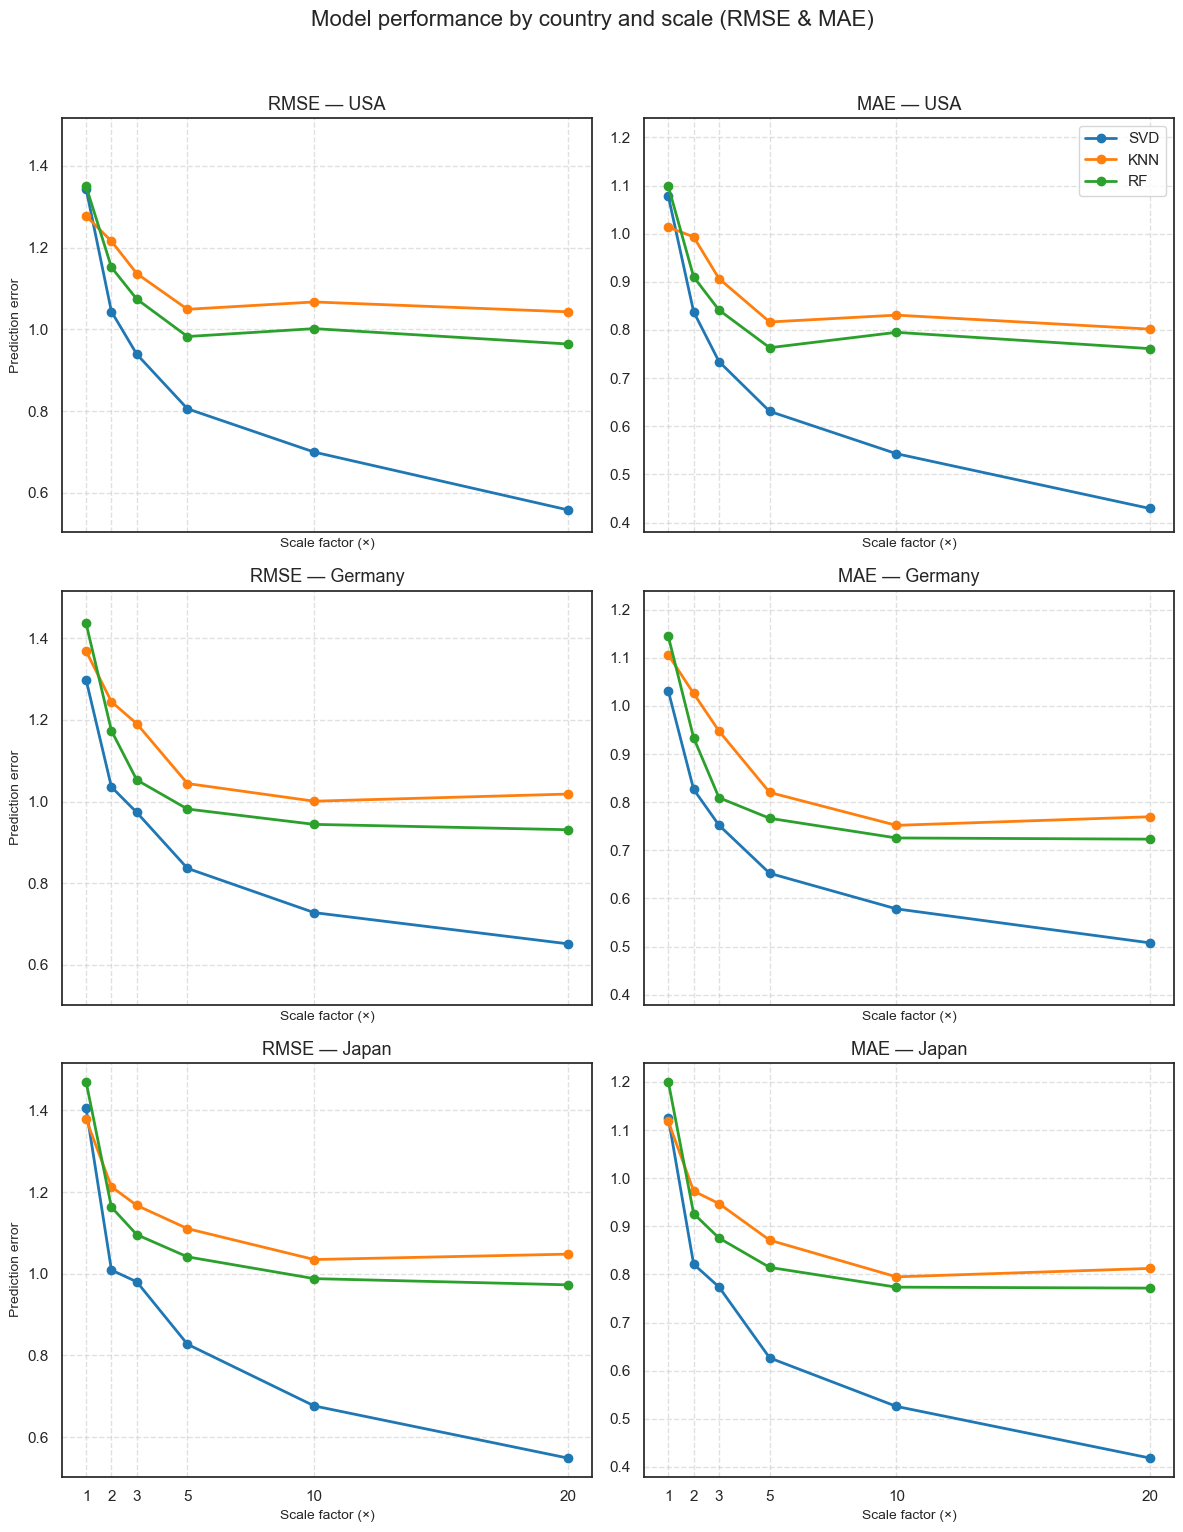

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

random.seed(42)
np.random.seed(42)

# Параметры
scales = [1, 2, 3, 5, 10, 20]
countries_h3 = ['USA', 'Germany', 'Japan']

# Хранилища для результатов
results_rmse = defaultdict(lambda: defaultdict(list))
results_mae = defaultdict(lambda: defaultdict(list))

for country in countries_h3:
    base_df = df_filtered[df_filtered['Country'] == country].copy()

    for scale in scales:
        scaled_df = pd.concat([base_df.copy() for _ in range(scale)], ignore_index=True)
        scaled_df['User_ID'] = scaled_df.groupby(['User_ID']).ngroup().astype(str) + f"_x{scale}"

        # Добавляем шум к рейтингам
        noise = np.random.normal(loc=0.0, scale=0.8, size=len(scaled_df))
        scaled_df['Rating'] = np.clip(scaled_df['Rating'] + noise, 1, 5)

        train_data, test_data = train_test_split(scaled_df, test_size=0.2, random_state=42)

        # SVD
        train_matrix = train_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
        test_matrix = test_data.groupby(['User_ID', 'Product'])['Rating'].mean().unstack()
        train_matrix = train_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

        svd = TruncatedSVD(n_components=5, random_state=42)
        reduced = svd.fit_transform(train_matrix)
        reconstructed = np.dot(reduced, svd.components_)
        reconstructed = np.clip(reconstructed, 1, 5)

        preds_svd, truths_svd = [], []
        for user_id in test_matrix.index:
            if user_id in train_matrix.index:
                for product in test_matrix.columns:
                    if product in train_matrix.columns:
                        true_val = test_matrix.loc[user_id, product]
                        if not np.isnan(true_val):
                            u_idx = train_matrix.index.get_loc(user_id)
                            p_idx = train_matrix.columns.get_loc(product)
                            preds_svd.append(reconstructed[u_idx, p_idx])
                            truths_svd.append(true_val)

        if preds_svd:
            results_rmse[country]['SVD'].append(mean_squared_error(truths_svd, preds_svd, squared=False))
            results_mae[country]['SVD'].append(mean_absolute_error(truths_svd, preds_svd))
        else:
            results_rmse[country]['SVD'].append(None)
            results_mae[country]['SVD'].append(None)

        # KNN & RF
        enc = LabelEncoder()
        scaled_df_tab = scaled_df.copy()
        scaled_df_tab['User_ID'] = enc.fit_transform(scaled_df_tab['User_ID'])
        scaled_df_tab['Product'] = enc.fit_transform(scaled_df_tab['Product'])

        train_data_tab, test_data_tab = train_test_split(scaled_df_tab, test_size=0.2, random_state=42)
        X_train = train_data_tab[['User_ID', 'Product']]
        y_train = train_data_tab['Rating']
        X_test = test_data_tab[['User_ID', 'Product']]
        y_test = test_data_tab['Rating']

        # KNN
        knn = KNeighborsRegressor(n_neighbors=5)
        knn.fit(X_train, y_train)
        preds_knn = knn.predict(X_test)
        results_rmse[country]['KNN'].append(mean_squared_error(y_test, preds_knn, squared=False))
        results_mae[country]['KNN'].append(mean_absolute_error(y_test, preds_knn))

        # RF
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        preds_rf = rf.predict(X_test)
        results_rmse[country]['RF'].append(mean_squared_error(y_test, preds_rf, squared=False))
        results_mae[country]['RF'].append(mean_absolute_error(y_test, preds_rf))

# Визуализация RMSE и MAE


# Цветовая палитра
color_map = {
    'SVD': '#1f77b4',    # синий
    'KNN': '#ff7f0e',    # оранжевый
    'RF': '#2ca02c'      # зелёный
}

fig, axs = plt.subplots(3, 2, figsize=(12, 15), sharex=True, sharey='col')

for row, country in enumerate(countries_h3):
    for col, (metric, result_dict) in enumerate([('RMSE', results_rmse), ('MAE', results_mae)]):
        ax = axs[row, col]
        for model in ['SVD', 'KNN', 'RF']:
            ax.plot(scales, result_dict[country][model],
                    marker='o', label=model, linewidth=2.0,
                    color=color_map[model])
        ax.set_title(f"{metric} — {country}", fontsize=13)
        ax.set_xticks(scales)
        ax.set_xlabel("Scale factor (×)", fontsize=10)
        if col == 0:
            ax.set_ylabel("Prediction error", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        if row == 0 and col == 1:
            ax.legend(loc='upper right')

plt.suptitle("Model performance by country and scale (RMSE & MAE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("H3_vertical_layout.png", dpi=300, bbox_inches='tight')
plt.show()